In [3475]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [3476]:
HERE = os.getcwd()
DATA_DIR = os.path.join(HERE, "data")


ROME_DIR = os.path.join(DATA_DIR, "rome")
PATH_RO = os.path.join(ROME_DIR, "listings_Rome.csv")
PATH_GEO_RO = os.path.join(ROME_DIR, "neighbourhoods_Rome.geojson")


COP_DIR = os.path.join(DATA_DIR, "copenhagen")
PATH_COP = os.path.join(COP_DIR, "listings_Copenhagen.csv")
PATH_GEO_COP = os.path.join(COP_DIR, "neighbourhoods_Copenhagen.geojson")

In [3477]:
df_rome = pd.read_csv(PATH_RO)
geo_rome = gpd.read_file(PATH_GEO_RO)

df_cop = pd.read_csv(PATH_COP)
geo_cop = gpd.read_file(PATH_GEO_COP)

## 2 - DATA UNDERSTANDING


In [3478]:
df_rome.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,...,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,5.00,4.89,4.83,it058091c2kv6epw8f,f,1,1,0,0,0.47
3,19965,https://www.airbnb.com/rooms/19965,20250914152919,2025-09-15,city scrape,S. Peter's Square 5 Min WALK bright and quite ...,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.90,4.54,IT058091C20YD35BX2,t,3,3,0,0,1.07
4,19967,https://www.airbnb.com/rooms/19967,20250914152919,2025-09-15,city scrape,*In front Vatican Museums 2 bedrooms quite bri...,"IN FRONT of the Vatican Museums entrance, at O...",Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.80,4.85,4.28,IT058091C20YD35BX2,t,3,3,0,0,0.32


In [3479]:
df_cop.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,23500,https://www.airbnb.com/rooms/23500,20250929042231,2025-09-29,city scrape,Nice room - great area (Vesterbro),Nice and cosy room in the heart of Copenhagen ...,NaN,https://a0.muscache.com/pictures/123766/fa4694...,92053,...,5.00,5.00,4.80,NaN,f,2,1,1,0,0.08
1,29118,https://www.airbnb.com/rooms/29118,20250929042231,2025-09-29,city scrape,Best Location in Cool Istedgade,NaN,NaN,https://a0.muscache.com/pictures/b83c7003-367a...,125230,...,5.00,4.84,4.74,NaN,f,1,1,0,0,0.15
2,31094,https://www.airbnb.com/rooms/31094,20250929042231,2025-09-30,previous scrape,"Beautiful, spacious, central, renovated Penthouse","Welcome to our home, we hope you will enjoy Wo...","What else is nearby?<br />To be honest, We thi...",https://a0.muscache.com/pictures/miso/Hosting-...,129976,...,4.82,4.80,4.53,NaN,f,1,1,0,0,0.10
3,32379,https://www.airbnb.com/rooms/32379,20250929042231,2025-09-30,previous scrape,"155 m2 artist flat on Vesterbro, with 2 bathrooms",You enter a narrow entrance and feel the good ...,"Værnedamsvej area is super hip area, we call i...",https://a0.muscache.com/pictures/miso/Hosting-...,140105,...,4.92,4.89,4.71,NaN,f,2,1,1,0,0.47
4,32841,https://www.airbnb.com/rooms/32841,20250929042231,2025-09-29,city scrape,Cozy flat for Adults/Quiet for kids,Our flat is placed in a Central AND Quiet neig...,NaN,https://a0.muscache.com/pictures/28047599/8efd...,142143,...,5.00,4.50,4.50,NaN,f,1,1,0,0,0.04


In [3480]:
print("Rome shape:", df_rome.shape)
print("Copenhagen shape:", df_cop.shape)

Rome shape: (37652, 79)
Copenhagen shape: (22994, 79)


In [3481]:
df_rome.columns.tolist()


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [3482]:
df_cop.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [3483]:
df_rome.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

In [3484]:
df_cop.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

## 4- DATA CLEANING 

In [3485]:
missing_rome = df_rome.isnull().sum().sort_values(ascending=False)
missing_cop = df_cop.isnull().sum().sort_values(ascending=False)


print("ROME - Missing values (top 15):")
print(missing_rome.head(15))

print("\nCOPENHAGEN - Missing values (top 15):")
print(missing_cop.head(15))

ROME - Missing values (top 15):
calendar_updated                37652
neighbourhood_group_cleansed    37652
host_neighbourhood              25411
host_about                      20255
neighbourhood                   19931
neighborhood_overview           19931
host_location                    9861
host_response_rate               6791
host_response_time               6791
review_scores_location           5400
review_scores_value              5399
review_scores_accuracy           5399
review_scores_checkin            5399
review_scores_communication      5398
review_scores_cleanliness        5398
dtype: int64

COPENHAGEN - Missing values (top 15):
neighbourhood_group_cleansed    22994
calendar_updated                22994
license                         22994
host_neighbourhood              18061
neighborhood_overview           15009
neighbourhood                   15009
host_about                      13352
beds                             9556
bathrooms                        9555
esti

In [3486]:
missing_pct_rome = (df_rome.isnull().mean() * 100).sort_values(ascending=False)
missing_pct_cop = (df_cop.isnull().mean() * 100).sort_values(ascending=False)

missing_pct_rome.head(15)

calendar_updated                100.000000
neighbourhood_group_cleansed    100.000000
host_neighbourhood               67.489111
host_about                       53.795283
neighbourhood                    52.934771
neighborhood_overview            52.934771
host_location                    26.189844
host_response_rate               18.036226
host_response_time               18.036226
review_scores_location           14.341868
review_scores_value              14.339212
review_scores_accuracy           14.339212
review_scores_checkin            14.339212
review_scores_communication      14.336556
review_scores_cleanliness        14.336556
dtype: float64

In [3487]:
missing_pct_cop.head(15)

neighbourhood_group_cleansed    100.000000
calendar_updated                100.000000
license                         100.000000
host_neighbourhood               78.546577
neighborhood_overview            65.273550
neighbourhood                    65.273550
host_about                       58.067322
beds                             41.558667
bathrooms                        41.554319
estimated_revenue_l365d          41.541272
price                            41.541272
host_response_time               36.392102
host_response_rate               36.392102
host_acceptance_rate             22.697225
host_location                    16.495608
dtype: float64

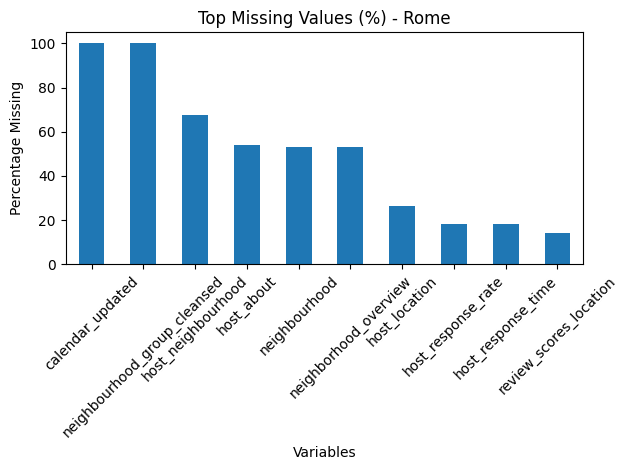

In [3488]:
top_missing = missing_pct_rome.head(10)

plt.figure()
top_missing.plot(kind='bar')
plt.title("Top Missing Values (%) - Rome")
plt.xlabel("Variables")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=45)
plt.tight_layout()


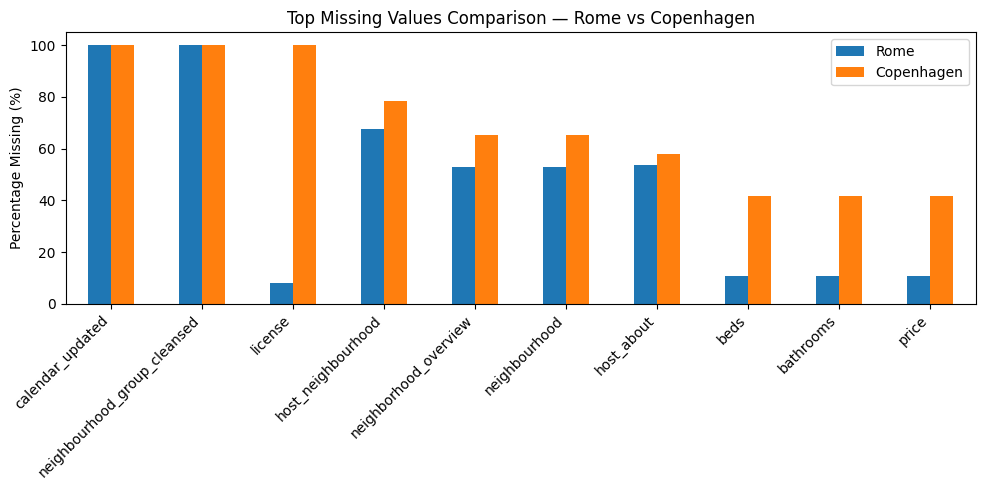

In [3489]:
compare_missing = pd.DataFrame({
    "Rome": missing_pct_rome,
    "Copenhagen": missing_pct_cop
}).fillna(0)

# show top 10 by maximum missing across either city
top_compare = compare_missing.loc[
    compare_missing.max(axis=1).sort_values(ascending=False).head(10).index
]

top_compare.plot(kind='bar', figsize=(10, 5))
plt.title("Top Missing Values Comparison — Rome vs Copenhagen")
plt.ylabel("Percentage Missing (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [3490]:
# --- FIX NEIGHBOURHOOD NAMES (encoding issues) ---
name_fixes = {
    "Nrrebro":      "Nørrebro",
    "sterbro":      "Østerbro",
    "Brnshj-Husum": "Brønshøj-Husum",
    "Amager st":    "Amager Øst",
    "Vanlse":       "Vanløse"
}

df_cop["neighbourhood"] = df_cop["neighbourhood"].replace(name_fixes)

# limiting the df to what is useful
Reduce the dataset to key variables capturing host activity, economic intensity, and spatial distribution, ensuring analytical focus and consistency with the objectives of measuring concentration and urban pressure.

In [3491]:

key_vars = [
    "host_id",
    "calculated_host_listings_count",
    "room_type",
    "price",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_revenue_l365d",
    "neighbourhood_cleansed",
    "latitude",
    "longitude"

]

df_rome = df_rome[key_vars].copy()
df_cop = df_cop[key_vars].copy()


In [3492]:
df_rome.head()

,host_id,calculated_host_listings_count,room_type,price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,estimated_revenue_l365d,neighbourhood_cleansed,latitude,longitude
0,3047,6,Private room,$57.00,31,365,5,0.04,0.0,VIII Appia Antica,41.871360,12.482150
1,44552,1,Entire home/apt,$110.00,2,295,284,1.62,19800.0,I Centro Storico,41.895447,12.491181
2,11756,1,Entire home/apt,$124.00,3,162,85,0.47,9672.0,II Parioli/Nomentano,41.925820,12.469280
3,75450,3,Entire home/apt,$162.00,3,187,178,1.07,20412.0,I Centro Storico,41.908230,12.452930
4,75450,3,Entire home/apt,$150.00,3,168,46,0.32,0.0,I Centro Storico,41.908283,12.452617


In [3493]:
df_cop.head()

,host_id,calculated_host_listings_count,room_type,price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,estimated_revenue_l365d,neighbourhood_cleansed,latitude,longitude
0,92053,2,Private room,$655.00,2,8,14,0.08,19650.0,Vesterbro-Kongens Enghave,55.663620,12.545420
1,125230,1,Entire home/apt,$900.00,7,43,28,0.15,12600.0,Vesterbro-Kongens Enghave,55.670230,12.555040
2,129976,1,Entire home/apt,NaN,3,0,19,0.10,NaN,Vesterbro-Kongens Enghave,55.666602,12.555283
3,140105,2,Entire home/apt,NaN,3,0,87,0.47,NaN,Vesterbro-Kongens Enghave,55.672638,12.552493
4,142143,1,Entire home/apt,$589.00,100,204,7,0.04,0.0,sterbro,55.711760,12.570910


Text(0, 0.5, 'Frequency')

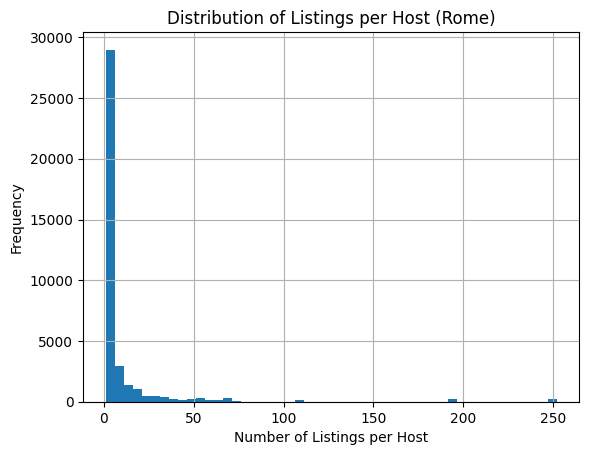

In [3494]:
plt.figure()

df_rome["calculated_host_listings_count"].hist(bins=50)

plt.title("Distribution of Listings per Host (Rome)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

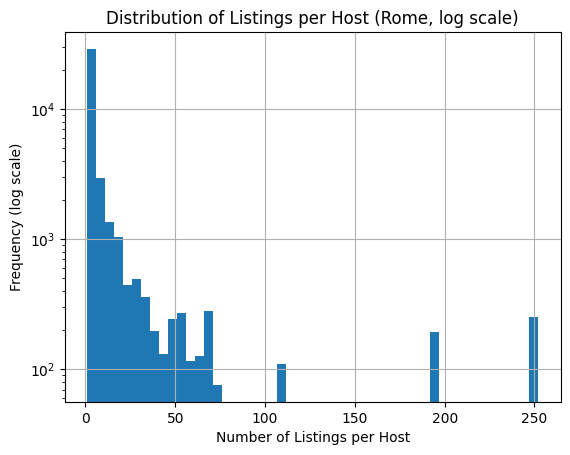

In [3495]:
plt.figure()

df_rome["calculated_host_listings_count"].hist(bins=50)

plt.yscale("log")

plt.title("Distribution of Listings per Host (Rome, log scale)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency (log scale)")



Text(0, 0.5, 'Frequency')

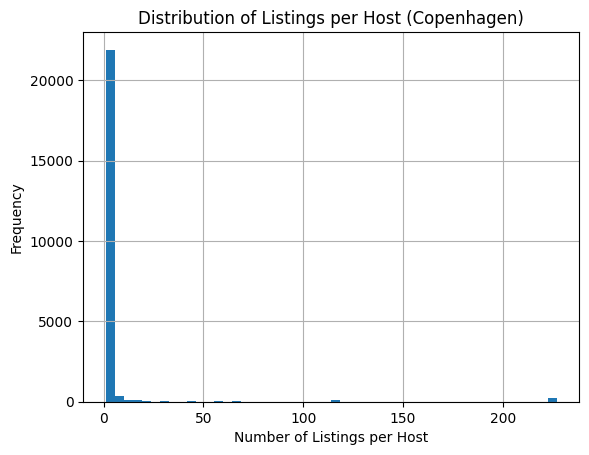

In [3496]:
plt.figure()

df_cop["calculated_host_listings_count"].hist(bins=50)

plt.title("Distribution of Listings per Host (Copenhagen)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

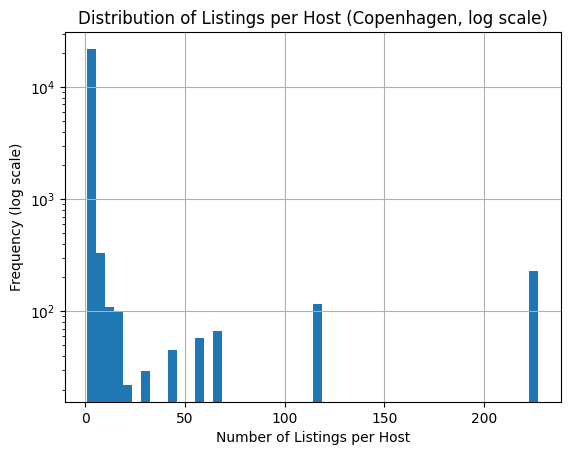

In [3497]:
plt.figure()

df_cop["calculated_host_listings_count"].hist(bins=50)

plt.yscale("log")

plt.title("Distribution of Listings per Host (Copenhagen, log scale)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency (log scale)")

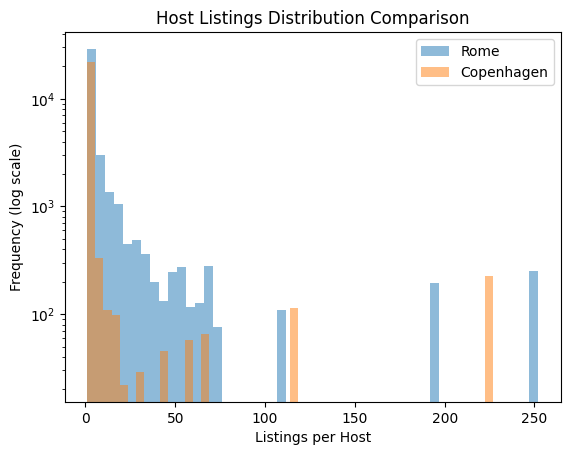

In [3498]:
plt.figure()

plt.hist(df_rome["calculated_host_listings_count"], bins=50, alpha=0.5, label="Rome")
plt.hist(df_cop["calculated_host_listings_count"], bins=50, alpha=0.5, label="Copenhagen")

plt.yscale("log")

plt.title("Host Listings Distribution Comparison")
plt.xlabel("Listings per Host")
plt.ylabel("Frequency (log scale)")
plt.legend()


# distributions

In [3499]:
for df in [df_rome, df_cop]:
    df["price"] = (
        df["price"]
        .replace(r"[\$,]", "", regex=True)
        .astype(float)
    )

In [3500]:
# Currency conversion: DKK → EUR
DKK_TO_EUR = 0.134
df_cop["price"] = df_cop["price"] * DKK_TO_EUR

print("Copenhagen price after conversion:")
print(df_cop["price"].describe().round(2))

Copenhagen price after conversion:
count    13442.00
mean       193.76
std        261.90
min         18.22
25%        120.60
50%        160.80
75%        222.84
max      15135.97
Name: price, dtype: float64


In [3501]:
print(df_rome["price"].describe())
print(df_cop["price"].describe())

count    33564.000000
mean       197.328000
std        443.190521
min          8.000000
25%         93.000000
50%        133.000000
75%        195.250000
max      10515.000000
Name: price, dtype: float64
count    13442.000000
mean       193.758118
std        261.899531
min         18.224000
25%        120.600000
50%        160.800000
75%        222.842000
max      15135.970000
Name: price, dtype: float64


Text(0, 0.5, 'Frequency')

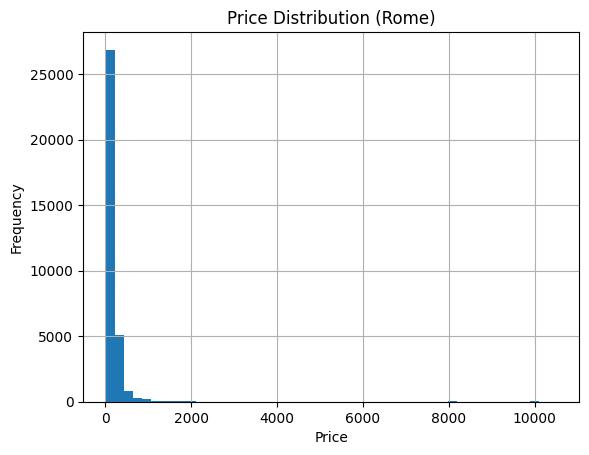

In [3502]:
plt.figure()
df_rome["price"].hist(bins=50)

plt.title("Price Distribution (Rome)")
plt.xlabel("Price")
plt.ylabel("Frequency")


Text(0, 0.5, 'Frequency (log scale)')

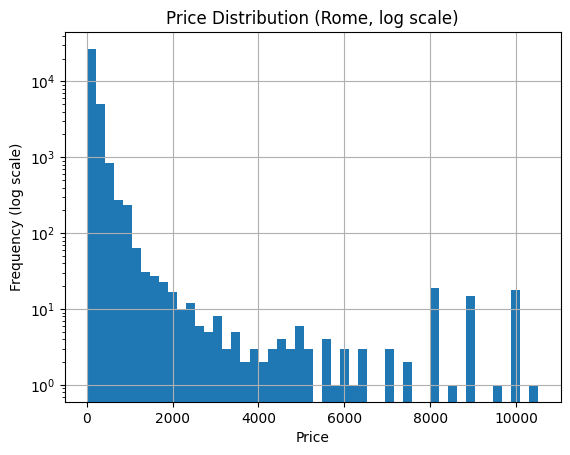

In [3503]:
plt.figure()
df_rome["price"].hist(bins=50)

plt.yscale("log")

plt.title("Price Distribution (Rome, log scale)")
plt.xlabel("Price")
plt.ylabel("Frequency (log scale)")

Text(0, 0.5, 'Frequency')

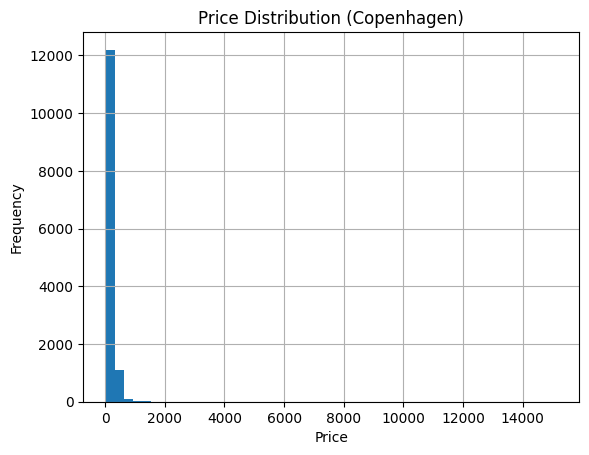

In [3504]:
plt.figure()
df_cop["price"].hist(bins=50)

plt.title("Price Distribution (Copenhagen)")
plt.xlabel("Price")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

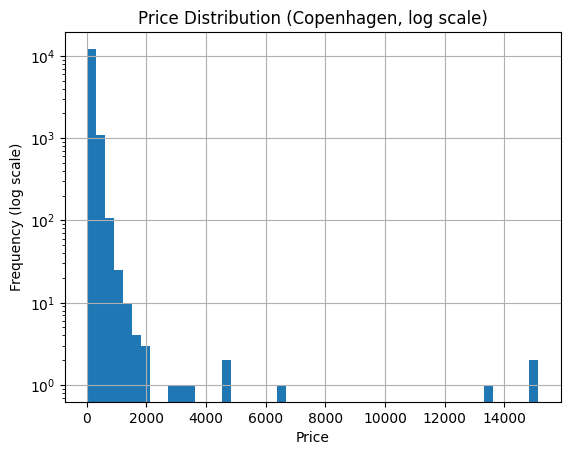

In [3505]:
plt.figure()
df_cop["price"].hist(bins=50)

plt.yscale("log")

plt.title("Price Distribution (Copenhagen, log scale)")
plt.xlabel("Price")
plt.ylabel("Frequency (log scale)")

Text(0, 0.5, 'Frequency')

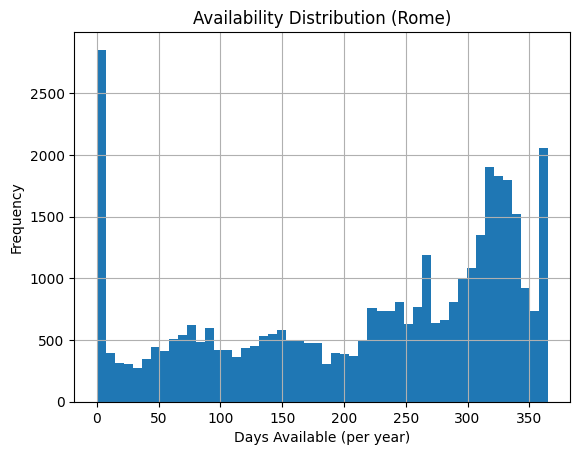

In [3506]:
plt.figure()
df_rome["availability_365"].hist(bins=50)

plt.title("Availability Distribution (Rome)")
plt.xlabel("Days Available (per year)")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

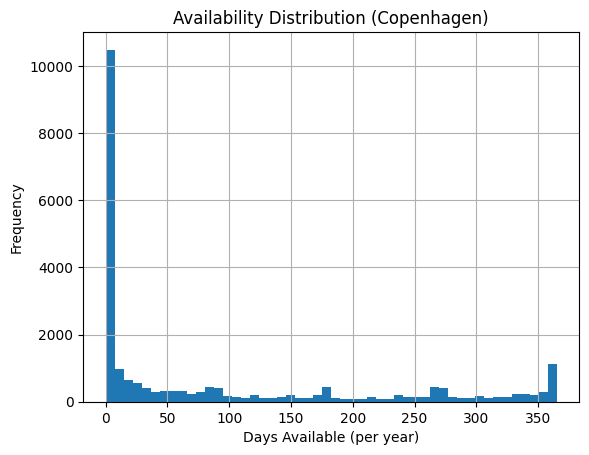

In [3507]:
plt.figure()
df_cop["availability_365"].hist(bins=50)

plt.title("Availability Distribution (Copenhagen)")
plt.xlabel("Days Available (per year)")
plt.ylabel("Frequency")

# neighbourhoods

In [3508]:
print("Rome neighbourhoods:", df_rome["neighbourhood_cleansed"].nunique())
print("Copenhagen neighbourhoods:", df_cop["neighbourhood_cleansed"].nunique())

Rome neighbourhoods: 15
Copenhagen neighbourhoods: 11


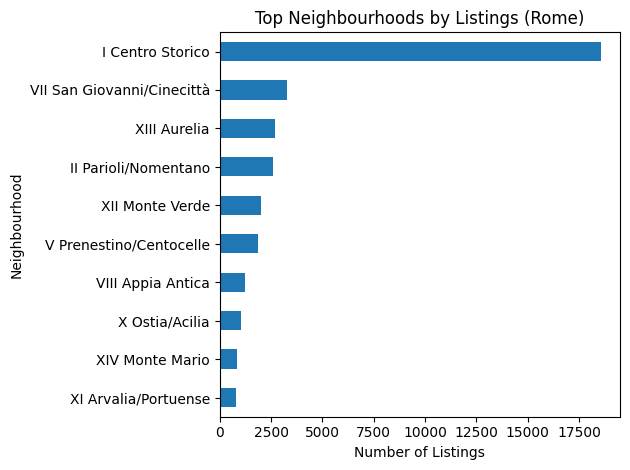

In [3509]:
top_neigh = df_rome["neighbourhood_cleansed"].value_counts().head(10)

plt.figure()

top_neigh.sort_values().plot(kind="barh")

plt.title("Top Neighbourhoods by Listings (Rome)")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.tight_layout()




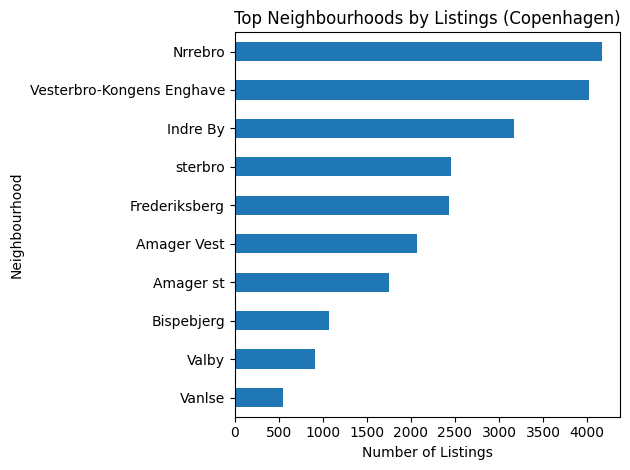

In [3510]:
top_neigh = df_cop["neighbourhood_cleansed"].value_counts().head(10)

plt.figure()

top_neigh.sort_values().plot(kind="barh")

plt.title("Top Neighbourhoods by Listings (Copenhagen)")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.tight_layout()

# check missing values for remaining columns

In [3511]:
df_rome.isnull().sum()


host_id                              0
calculated_host_listings_count       0
room_type                            0
price                             4088
minimum_nights                       0
availability_365                     0
number_of_reviews                    0
reviews_per_month                 5397
estimated_revenue_l365d           4088
neighbourhood_cleansed               0
latitude                             0
longitude                            0
dtype: int64

In [3512]:
df_cop.isnull().sum()

host_id                              0
calculated_host_listings_count       0
room_type                            0
price                             9552
minimum_nights                       0
availability_365                     0
number_of_reviews                    0
reviews_per_month                 2371
estimated_revenue_l365d           9552
neighbourhood_cleansed               0
latitude                             0
longitude                            0
dtype: int64

In [3513]:
missing_pct_rome = (df_rome.isnull().mean() * 100).sort_values(ascending=False)
missing_pct_cop = (df_cop.isnull().mean() * 100).sort_values(ascending=False)

missing_pct_rome.head(15)

reviews_per_month                 14.333900
price                             10.857325
estimated_revenue_l365d           10.857325
host_id                            0.000000
calculated_host_listings_count     0.000000
room_type                          0.000000
minimum_nights                     0.000000
availability_365                   0.000000
number_of_reviews                  0.000000
neighbourhood_cleansed             0.000000
latitude                           0.000000
longitude                          0.000000
dtype: float64

In [3514]:
missing_pct_cop.head(15)

price                             41.541272
estimated_revenue_l365d           41.541272
reviews_per_month                 10.311386
host_id                            0.000000
calculated_host_listings_count     0.000000
room_type                          0.000000
minimum_nights                     0.000000
availability_365                   0.000000
number_of_reviews                  0.000000
neighbourhood_cleansed             0.000000
latitude                           0.000000
longitude                          0.000000
dtype: float64

In [3515]:
df_rome = df_rome.dropna(subset=["price"])
df_cop = df_cop.dropna(subset=["price"])

# outliers


/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_11583/2976862680.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


Text(0.5, 0, 'Price')

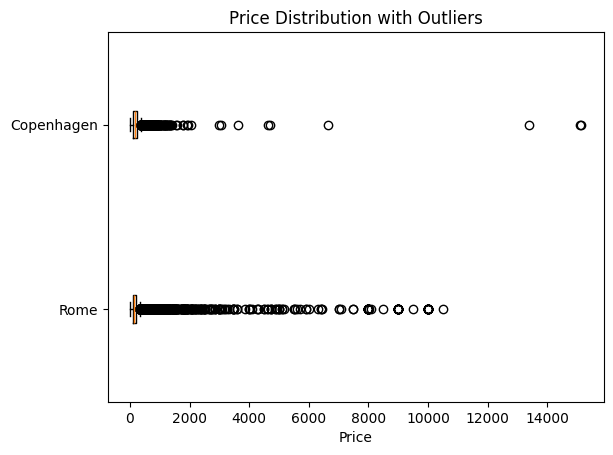

In [3516]:
plt.figure()

plt.boxplot(
    [df_rome["price"], df_cop["price"]],
    labels=["Rome", "Copenhagen"],
    vert=False
)

plt.title("Price Distribution with Outliers")
plt.xlabel("Price")




Text(0.5, 0, 'Price (log scale)')

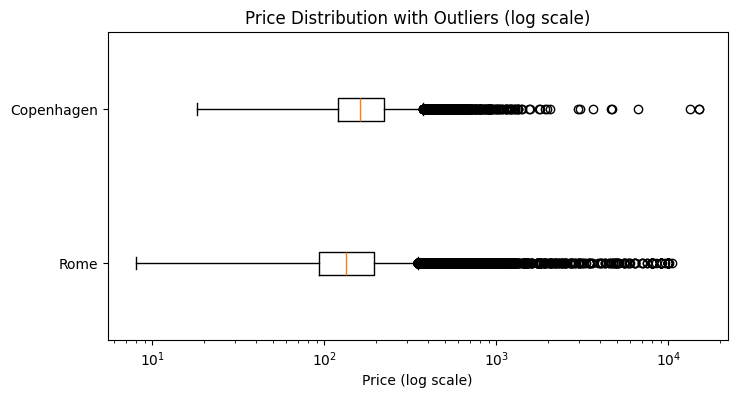

In [3517]:
plt.figure(figsize=(8,4))

plt.boxplot(
    [df_rome["price"], df_cop["price"]],
    tick_labels=["Rome", "Copenhagen"],
    vert=False
)

plt.xscale("log")
plt.title("Price Distribution with Outliers (log scale)")
plt.xlabel("Price (log scale)")


In [3518]:
# Compute thresholds
p99_rome = df_rome["price"].quantile(0.99)
p99_cop  = df_cop["price"].quantile(0.99)

print(f"Rome 99th percentile:       €{p99_rome:.2f}")
print(f"Copenhagen 99th percentile: €{p99_cop:.2f}")

# Store size before
rome_before = len(df_rome)
cop_before  = len(df_cop)

# Apply filtering
df_rome = df_rome[df_rome["price"] <= p99_rome]
df_cop  = df_cop[df_cop["price"]  <= p99_cop]

# Report impact
print(f"\nRome:       {rome_before} → {len(df_rome)} rows ({rome_before - len(df_rome)} dropped)")
print(f"Copenhagen: {cop_before} → {len(df_cop)} rows ({cop_before - len(df_cop)} dropped)")

Rome 99th percentile:       €1005.74
Copenhagen 99th percentile: €658.12

Rome:       33564 → 33228 rows (336 dropped)
Copenhagen: 13442 → 13307 rows (135 dropped)


In [3519]:
print("\nAfter cleaning:")
print(df_rome["price"].describe().round(2))
print(df_cop["price"].describe().round(2))


After cleaning:
count    33228.00
mean       165.78
std        123.87
min          8.00
25%         93.00
50%        132.00
75%        192.00
max       1005.00
Name: price, dtype: float64
count    13307.00
mean       181.80
std         92.26
min         18.22
25%        120.60
50%        160.80
75%        219.42
max        656.06
Name: price, dtype: float64


In [3520]:
# def remove_outliers_iqr(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     return df[(df[column] >= lower) & (df[column] <= upper)]

In [3521]:
# df_rome = remove_outliers_iqr(df_rome, "price")


In [3522]:
# df_cop = remove_outliers_iqr(df_cop, "price")

# standardize names


In [3523]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

In [3524]:
df_rome = clean_columns(df_rome)
df_cop = clean_columns(df_cop)

In [3525]:
df_rome["city"] = "Rome"
df_cop["city"] = "Copenhagen"

In [3526]:
df_rome.rename(columns={
    "neighbourhood_cleansed": "neighbourhood"
}, inplace=True)

df_cop.rename(columns={
    "neighbourhood_cleansed": "neighbourhood"
}, inplace=True)

Text(0.5, 1.0, 'Price Distribution After Cleaning (Rome)')

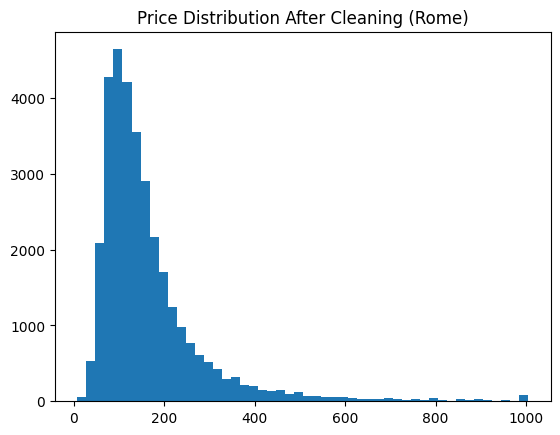

In [3527]:
plt.figure()
plt.hist(df_rome["price"], bins=50)
plt.title("Price Distribution After Cleaning (Rome)")


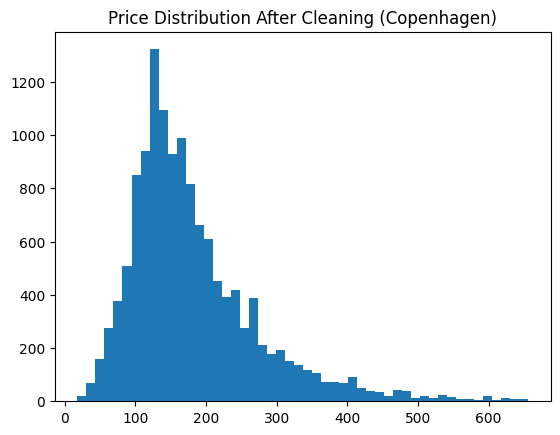

In [3528]:
plt.figure()
plt.hist(df_cop["price"], bins=50)
plt.title("Price Distribution After Cleaning (Copenhagen)")
plt.show()

# 5 - DATA INTEGRATION

In [3529]:
print("ROME:")
print(df_rome.columns)

print("\nCOPENHAGEN:")
print(df_cop.columns)

ROME:
Index(['host_id', 'calculated_host_listings_count', 'room_type', 'price',
       'minimum_nights', 'availability_365', 'number_of_reviews',
       'reviews_per_month', 'estimated_revenue_l365d', 'neighbourhood',
       'latitude', 'longitude', 'city'],
      dtype='str')

COPENHAGEN:
Index(['host_id', 'calculated_host_listings_count', 'room_type', 'price',
       'minimum_nights', 'availability_365', 'number_of_reviews',
       'reviews_per_month', 'estimated_revenue_l365d', 'neighbourhood',
       'latitude', 'longitude', 'city'],
      dtype='str')


# merge datasets

In [3530]:
df = pd.concat([df_rome, df_cop], ignore_index=True)


In [3531]:
df = df[df["room_type"].notna()]

In [3532]:
df.groupby("city")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Copenhagen,13307.0,181.801789,92.257059,18.224,120.6,160.8,219.425,656.064
Rome,33228.0,165.777597,123.873342,8.000,93.0,132.0,192.000,1005.000


In [3533]:
print(f"Rome:        {len(df_rome):,} rows")
print(f"Copenhagen:  {len(df_cop):,} rows")
print(f"Combined:    {len(df):,} rows")

assert len(df) == len(df_rome) + len(df_cop)

print(f"\nShape: {df.shape}")
print(f"Cities: {df['city'].value_counts().to_dict()}")

print("\nMissing values:")
print(df.isnull().sum())

Rome:        33,228 rows
Copenhagen:  13,307 rows
Combined:    46,535 rows

Shape: (46535, 13)
Cities: {'Rome': 33228, 'Copenhagen': 13307}

Missing values:
host_id                              0
calculated_host_listings_count       0
room_type                            0
price                                0
minimum_nights                       0
availability_365                     0
number_of_reviews                    0
reviews_per_month                 5678
estimated_revenue_l365d              0
neighbourhood                        0
latitude                             0
longitude                            0
city                                 0
dtype: int64


# 6 - FEATURE ENGINEERING


LISTING PER HOST

In [3534]:
# --- STEP 6.1: Listings per host ---

# Compute listings per host (per city)
host_counts = (
    df.groupby(["city", "host_id"])
    .size()
    .rename("host_listings_local")
    .reset_index()
)

# Merge into main dataset
df = df.merge(host_counts, on=["city", "host_id"], how="left")

# Validate against original column
df["count_diff"] = df["calculated_host_listings_count"] - df["host_listings_local"]

print("Difference between calculated and local count:")
print(df["count_diff"].describe().round(2))

print(f"\nListings where counts differ: {(df['count_diff'] != 0).sum():,}")
print(f"Total listings: {len(df):,}")

# NOTE:
# The original variable 'calculated_host_listings_count' differs from the 
# locally computed counts due to dataset filtering and cleaning.
# Therefore, we use 'host_listings_local' as the reference variable.

Difference between calculated and local count:
count    46535.00
mean         0.64
std          2.71
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         31.00
Name: count_diff, dtype: float64

Listings where counts differ: 7,381
Total listings: 46,535


host classification

In [3535]:
def classify_host(n):
    if n == 1:
        return "Casual"
    elif n <= 4:
        return "Semi-professional"
    else:
        return "Professional"

df["host_category"] = df["host_listings_local"].apply(classify_host)

# Quick distribution check
print(df.groupby(["city", "host_category"]).size())

city        host_category    
Copenhagen  Casual               11350
            Professional          1042
            Semi-professional      915
Rome        Casual               13810
            Professional          9766
            Semi-professional     9652
dtype: int64


In [3536]:
# --- ROOM TYPE BY HOST CATEGORY ---

room_host = (
    df.groupby(["city", "host_category", "room_type"])
    .size()
    .reset_index(name="count")
)

room_host["share"] = (
    room_host.groupby(["city", "host_category"])["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

room_host

,city,host_category,room_type,count,share
0,Copenhagen,Casual,Entire home/apt,10698,94.3
1,Copenhagen,Casual,Private room,650,5.7
2,Copenhagen,Casual,Shared room,2,0.0
3,Copenhagen,Professional,Entire home/apt,914,87.7
4,Copenhagen,Professional,Private room,116,11.1
5,Copenhagen,Professional,Shared room,12,1.2
6,Copenhagen,Semi-professional,Entire home/apt,556,60.8
7,Copenhagen,Semi-professional,Hotel room,3,0.3
8,Copenhagen,Semi-professional,Private room,353,38.6
9,Copenhagen,Semi-professional,Shared room,3,0.3


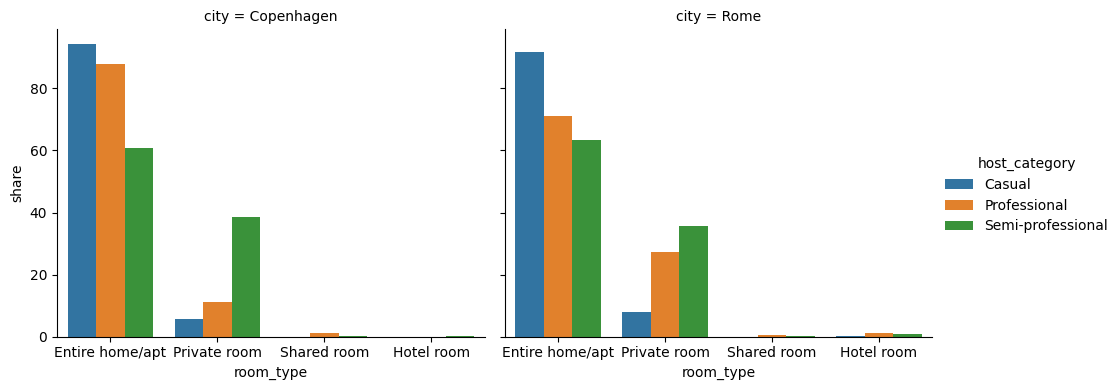

In [3537]:
sns.catplot(
    data=room_host,
    x="room_type",
    y="share",
    hue="host_category",
    col="city",
    kind="bar",
    height=4,
    aspect=1.2
)

Neighbourhood aggregates

In [3538]:
# --- STEP 6.3: Neighbourhood aggregates ---

neighbourhood_stats = (
    df.groupby(["city", "neighbourhood"])
    .agg(
        listing_count       = ("host_id", "size"),
        avg_price           = ("price", "mean"),
        avg_availability    = ("availability_365", "mean"),
        professional_share  = (
            "host_category",
            lambda x: (x == "Professional").mean()
        )
    )
    .reset_index()
)

# Convert to percentage
neighbourhood_stats["professional_share"] *= 100

# Quick check
print(neighbourhood_stats.shape)
neighbourhood_stats.head()

(26, 6)


,city,neighbourhood,listing_count,avg_price,avg_availability,professional_share
0,Copenhagen,Amager Vest,1225,182.267675,146.664490,8.000000
1,Copenhagen,Amager st,1020,167.886498,143.486275,8.137255
2,Copenhagen,Bispebjerg,595,135.060289,158.695798,8.739496
3,Copenhagen,Brnshj-Husum,232,144.650690,177.521552,3.879310
4,Copenhagen,Frederiksberg,1402,183.692208,150.256776,4.065621


## UPI


Normalization without price

In [3539]:
# --- STEP 6.4: Normalisation for UPI (final version) ---


scaler = MinMaxScaler()

# Normalise within each city separately
# Price is excluded due to missing values (data bias issue)

for city in ["Rome", "Copenhagen"]:
    mask = neighbourhood_stats["city"] == city

    neighbourhood_stats.loc[mask, "listing_count_norm"] = scaler.fit_transform(
        neighbourhood_stats.loc[mask, ["listing_count"]]
    )
    
    neighbourhood_stats.loc[mask, "availability_norm"] = scaler.fit_transform(
        neighbourhood_stats.loc[mask, ["avg_availability"]]
    )

print("Normalisation complete.")
neighbourhood_stats[
    ["city", "neighbourhood", "listing_count_norm", "availability_norm"]
].head(10)

Normalisation complete.


,city,neighbourhood,listing_count_norm,availability_norm
0,Copenhagen,Amager Vest,0.483447,0.241067
1,Copenhagen,Amager st,0.383642,0.162899
2,Copenhagen,Bispebjerg,0.176728,0.536979
3,Copenhagen,Brnshj-Husum,0.000000,1.000000
4,Copenhagen,Frederiksberg,0.569620,0.329420
5,Copenhagen,Indre By,0.896787,0.971803
6,Copenhagen,Nrrebro,0.967868,0.000000
7,Copenhagen,Valby,0.118306,0.364942
8,Copenhagen,Vanlse,0.048199,0.464582
9,Copenhagen,Vesterbro-Kongens Enghave,1.000000,0.175598


upi

In [3540]:
# --- STEP 6.5: Urban Pressure Index (UPI) ---

# Equal weighting between density and availability
neighbourhood_stats["UPI"] = (
    0.5 * neighbourhood_stats["listing_count_norm"] +
    0.5 * neighbourhood_stats["availability_norm"]
).round(4)

print("UPI distribution by city:")
print(neighbourhood_stats.groupby("city")["UPI"].describe().round(3))

UPI distribution by city:
            count   mean    std    min    25%    50%    75%    max
city                                                              
Copenhagen   11.0  0.442  0.197  0.242  0.315  0.412  0.492  0.934
Rome         15.0  0.270  0.180  0.040  0.169  0.244  0.363  0.666


top area by UPI

In [3541]:
for city in ["Rome", "Copenhagen"]:
    print(f"\n--- {city} — top 5 neighbourhoods by UPI ---")
    
    top = (
        neighbourhood_stats[neighbourhood_stats["city"] == city]
        .sort_values("UPI", ascending=False)
        .head(5)
    )
    
    print(
        top[
            ["neighbourhood", "listing_count", "avg_availability", "UPI"]
        ].to_string(index=False)
    )


--- Rome — top 5 neighbourhoods by UPI ---
      neighbourhood  listing_count  avg_availability    UPI
   I Centro Storico          16310        230.071245 0.6661
 XV Cassia/Flaminia            524        249.143130 0.5066
VI Roma delle Torri            312        246.717949 0.4575
             IX Eur            383        243.080940 0.3961
    XIV Monte Mario            769        238.603381 0.3298

--- Copenhagen — top 5 neighbourhoods by UPI ---
            neighbourhood  listing_count  avg_availability    UPI
                 Indre By           2074        176.375121 0.9343
Vesterbro-Kongens Enghave           2286        144.002625 0.5878
             Brnshj-Husum            232        177.521552 0.5000
                  Nrrebro           2220        136.863063 0.4839
            Frederiksberg           1402        150.256776 0.4495


upi with price

In [3542]:
# --- OPTIONAL: Alternative UPI including price (not used in final analysis) ---

# This version is exploratory and not used due to missing price data in Copenhagen
scaler = MinMaxScaler()

for city in ["Rome", "Copenhagen"]:
    mask = neighbourhood_stats["city"] == city
    
    neighbourhood_stats.loc[mask, "price_norm"] = scaler.fit_transform(
        neighbourhood_stats.loc[mask, ["avg_price"]]
    )

neighbourhood_stats["UPI_alt"] = (
    (1/3) * neighbourhood_stats["listing_count_norm"] +
    (1/3) * neighbourhood_stats["availability_norm"] +
    (1/3) * neighbourhood_stats["price_norm"]
).round(4)

## 7 - EXPLORATORY ANALYSIS

Price distribution

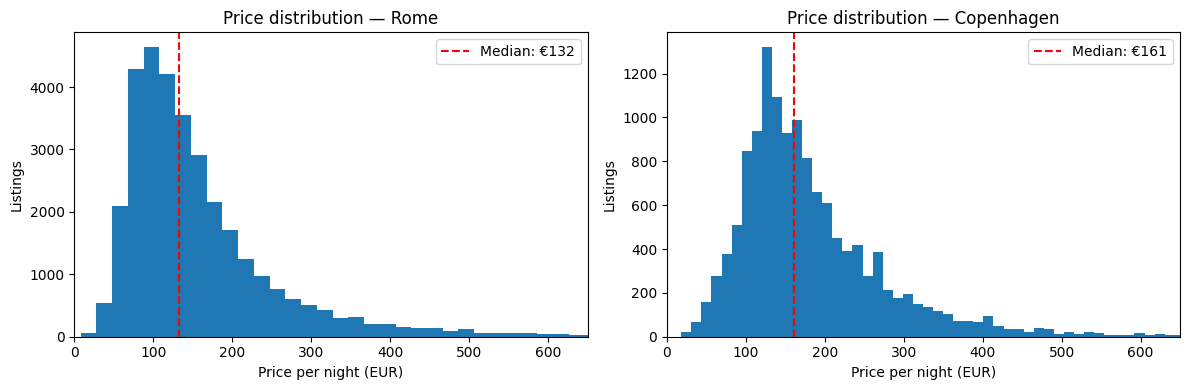

In [3543]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

upper = df["price"].quantile(0.99)

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["price"]
    
    ax.hist(subset, bins=50, edgecolor="none")
    ax.set_xlim(0, upper)
    
    ax.set_title(f"Price distribution — {city}")
    ax.set_xlabel("Price per night (EUR)")
    ax.set_ylabel("Listings")
    
    ax.axvline(subset.median(), color="red", linestyle="--",
               label=f"Median: €{subset.median():.0f}")
    ax.legend()

plt.tight_layout()

listing per host

Rome: 41.6% single-listing hosts, max 223 listings
Copenhagen: 85.3% single-listing hosts, max 223 listings


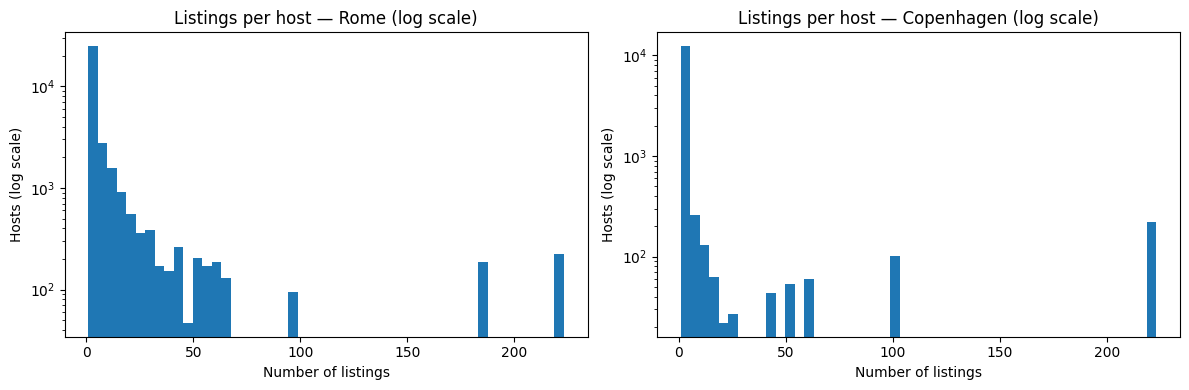

In [3544]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["host_listings_local"]
    
    ax.hist(subset, bins=50)
    ax.set_yscale("log")
    
    ax.set_title(f"Listings per host — {city} (log scale)")
    ax.set_xlabel("Number of listings")
    ax.set_ylabel("Hosts (log scale)")

plt.tight_layout()

# Summary
for city in ["Rome", "Copenhagen"]:
    s = df[df["city"] == city]["host_listings_local"]
    print(f"{city}: {(s == 1).mean()*100:.1f}% single-listing hosts, max {s.max()} listings")

Listing share by host category

In [3545]:
listing_share = (
    df.groupby(["city", "host_category"])
    .size()
    .reset_index(name="listing_count")
)

listing_share["share"] = (
    listing_share.groupby("city")["listing_count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

print(listing_share.sort_values(["city", "host_category"]))

         city      host_category  listing_count  share
0  Copenhagen             Casual          11350   85.3
1  Copenhagen       Professional           1042    7.8
2  Copenhagen  Semi-professional            915    6.9
3        Rome             Casual          13810   41.6
4        Rome       Professional           9766   29.4
5        Rome  Semi-professional           9652   29.0


Availability distribution

Rome: median 260 days, 67.9% available > 6 months
Copenhagen: median 115 days, 38.1% available > 6 months


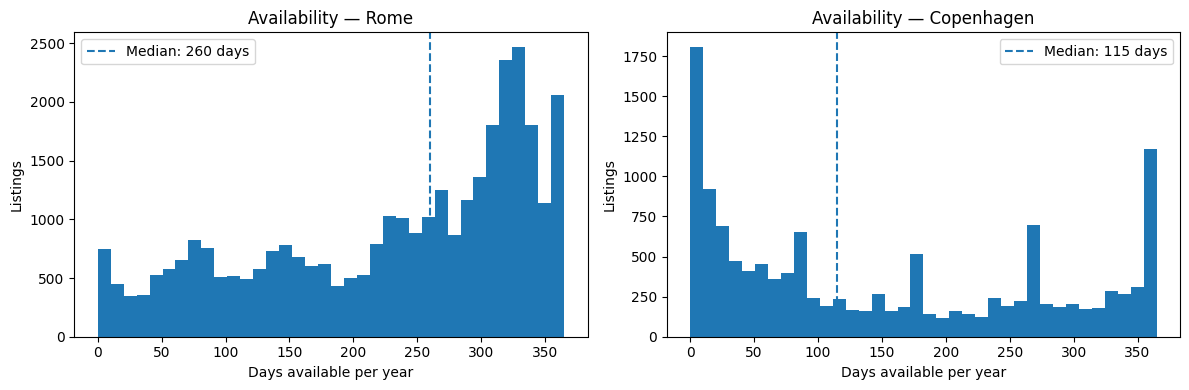

In [3546]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["availability_365"]
    
    ax.hist(subset, bins=36)
    ax.set_title(f"Availability — {city}")
    ax.set_xlabel("Days available per year")
    ax.set_ylabel("Listings")
    
    ax.axvline(subset.median(), linestyle="--",
               label=f"Median: {subset.median():.0f} days")
    ax.legend()

plt.tight_layout()

# Summary
for city in ["Rome", "Copenhagen"]:
    s = df[df["city"] == city]["availability_365"]
    print(f"{city}: median {s.median():.0f} days, {(s > 180).mean()*100:.1f}% available > 6 months")

In [3547]:
room_share = (
    df.groupby(["city", "room_type"])
    .size()
    .reset_index(name="count")
)

room_share["share"] = (
    room_share.groupby("city")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

room_share

,city,room_type,count,share
0,Copenhagen,Entire home/apt,12168,91.4
1,Copenhagen,Hotel room,3,0.0
2,Copenhagen,Private room,1119,8.4
3,Copenhagen,Shared room,17,0.1
4,Rome,Entire home/apt,25739,77.5
5,Rome,Hotel room,204,0.6
6,Rome,Private room,7209,21.7
7,Rome,Shared room,76,0.2


/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_11583/2855376832.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["room_type"], rotation=30)
/var/folders/sy/rj38yfc5325c80xyvrvsb31m0000gn/T/ipykernel_11583/2855376832.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset["room_type"], rotation=30)


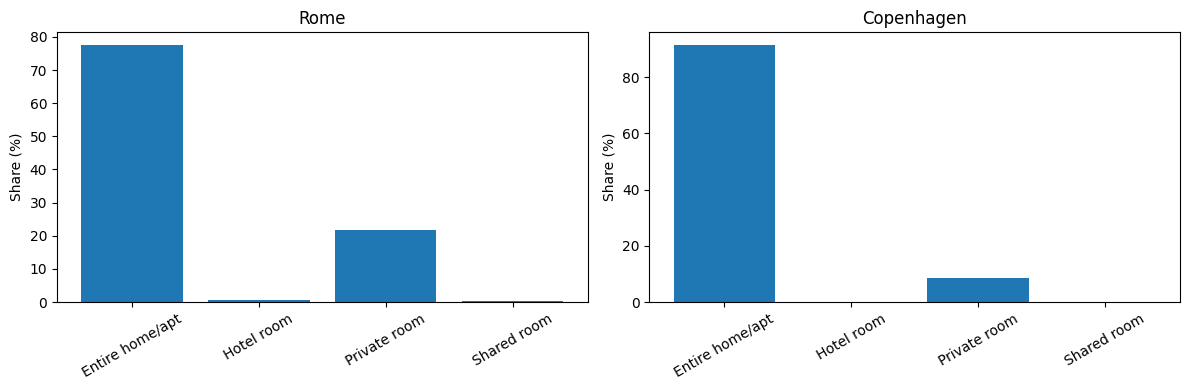

In [3548]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, city in zip(axes, df["city"].unique()):
    subset = room_share[room_share["city"] == city]
    ax.bar(subset["room_type"], subset["share"])
    ax.set_title(f"{city}")
    ax.set_ylabel("Share (%)")
    ax.set_xticklabels(subset["room_type"], rotation=30)

plt.tight_layout()

In [3549]:
df.groupby("city")["minimum_nights"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Copenhagen,13307.0,4.140828,12.105535,1.0,2.0,3.0,4.0,730.0
Rome,33228.0,4.254484,14.125233,1.0,1.0,2.0,3.0,730.0


## 7.5 - INSIGHT EXTRACTION

Before moving to formal metrics, we summarise the key patterns emerging from the exploratory analysis. These observations guide both the interpretation of results and the validation of cross-city differences.

⸻

I1 — Market professionalisation is structurally higher in Rome.
In Rome, only 43.2% of listings belong to single-listing hosts, while professional hosts (5+ listings) control 29.4% of the market. In contrast, Copenhagen shows a strongly decentralized structure: 85.9% of listings are managed by single-listing hosts, while only 7.8% are controlled by professionals. This indicates a fundamentally different market organisation, with Rome exhibiting a high degree of commercialisation compared to a predominantly peer-to-peer model in Copenhagen.

⸻

I2 — Listing availability reveals different usage models.
Rome exhibits significantly higher availability, with a median of 258 days per year and 67.4% of listings available for more than six months. In Copenhagen, the median availability is 108 days, with only 37.4% exceeding six months. This suggests that listings in Rome are operated on a near-continuous basis, while Copenhagen reflects a more intermittent usage pattern consistent with occasional hosting.

⸻

I3 — Prices are higher in Copenhagen despite lower concentration.
The median price in Copenhagen (€160.8) exceeds that of Rome (€126), despite the lower level of professionalisation. This counterintuitive pattern suggests that price dynamics are not driven solely by host concentration, but may reflect constrained supply and broader housing market conditions in Copenhagen.

⸻

I4 — Entire-home listings reinforce housing market impact.
In both cities, the majority of listings consist of entire homes, indicating that Airbnb activity directly affects the availability of residential housing. However, the impact differs in intensity: in Rome, the combination of entire-home dominance with high availability suggests a sustained removal of housing units from the long-term market, whereas in Copenhagen the lower availability reduces this effect despite a similar structural composition.

⸻

I5 — Spatial concentration is significantly more intense in Rome.
Rome shows extreme spatial clustering, with neighbourhoods such as Centro Storico reaching 16,310 listings and a professional share of 38.84%. In Copenhagen, the most active area (Indre By) reaches approximately 2,074 listings with a professional share of 20.59%. This indicates that Airbnb pressure in Rome is both more concentrated and more commercially driven.

⸻

I6 — Structural differences suggest the influence of contextual factors beyond market dynamics.
The contrast between Rome and Copenhagen cannot be explained by market forces alone. Differences in housing market structure, tourism intensity, and — potentially — regulatory frameworks likely contribute to the observed patterns. However, testing these hypotheses falls outside the scope of this analysis and represents a direction for future research.

⸻

I7 — Urban pressure emerges from different underlying mechanisms.
The Urban Pressure Index highlights an important asymmetry between the two cities. In Rome, high pressure is driven primarily by listing density and professional host concentration. In Copenhagen, pressure emerges from a smaller number of listings combined with relatively high availability in specific areas. This suggests that similar levels of measured pressure may correspond to fundamentally different urban dynamics.

## 8 - ANALYTICAL METRICS

In [3550]:
for city in ["Rome", "Copenhagen"]:
    print(f"\n--- {city} — full UPI ranking ---")
    ranked = (
        neighbourhood_stats[neighbourhood_stats["city"] == city]
        .sort_values("UPI", ascending=False)
        [["neighbourhood", "listing_count", "avg_availability", 
          "professional_share", "UPI"]]
    )
    print(ranked.to_string(index=False))




--- Rome — full UPI ranking ---
             neighbourhood  listing_count  avg_availability  professional_share    UPI
          I Centro Storico          16310        230.071245           38.835071 0.6661
        XV Cassia/Flaminia            524        249.143130           24.045802 0.5066
       VI Roma delle Torri            312        246.717949           10.256410 0.4575
                    IX Eur            383        243.080940           13.838120 0.3961
           XIV Monte Mario            769        238.603381           23.146944 0.3298
         VIII Appia Antica           1079        237.047266           22.057461 0.3122
              XIII Aurelia           2435        231.429158           24.394251 0.2562
VII San Giovanni/Cinecittà           2944        229.847486           20.448370 0.2445
      II Parioli/Nomentano           2253        229.563249           27.607634 0.2179
      XI Arvalia/Portuense            634        231.214511           14.353312 0.1962
          

Lorenz curve

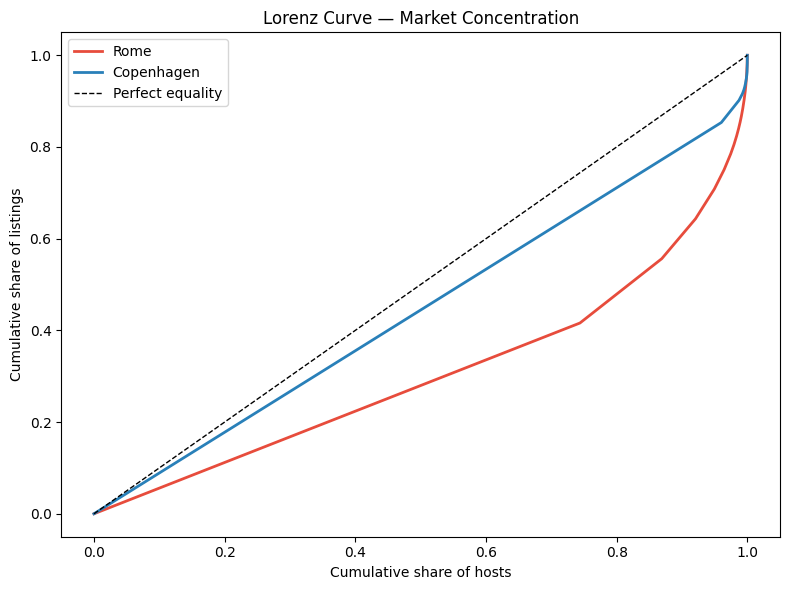

In [3551]:
def lorenz_curve(values):
    sorted_vals = np.sort(values)
    cumulative = np.cumsum(sorted_vals)
    cumulative = cumulative / cumulative[-1]
    x = np.linspace(0, 1, len(cumulative))
    return x, cumulative

fig, ax = plt.subplots(figsize=(8, 6))

for city, color in [("Rome", "#e74c3c"), ("Copenhagen", "#2980b9")]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .values
    )
    x, y = lorenz_curve(host_data)
    ax.plot(x, y, label=city, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect equality")

ax.set_xlabel("Cumulative share of hosts")
ax.set_ylabel("Cumulative share of listings")
ax.set_title("Lorenz Curve — Market Concentration")
ax.legend()

plt.tight_layout()

Gini 

In [3552]:
def gini(values):
    sorted_vals = np.sort(values)
    n = len(sorted_vals)
    cumulative = np.cumsum(sorted_vals)
    return (2 * np.sum((np.arange(1, n+1) * sorted_vals)) 
            / (n * cumulative[-1])) - (n + 1) / n

for city in ["Rome", "Copenhagen"]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .values
    )
    g = gini(host_data)
    print(f"{city} Gini coefficient: {g:.4f}")

Rome Gini coefficient: 0.3873
Copenhagen Gini coefficient: 0.1098


Top host dominance

In [3553]:
for city in ["Rome", "Copenhagen"]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .sort_values(ascending=False)
    )
    
    total   = host_data.sum()
    top_1p  = host_data.iloc[:max(1, int(len(host_data) * 0.01))].sum()
    top_10p = host_data.iloc[:max(1, int(len(host_data) * 0.10))].sum()
    
    print(f"\n{city}")
    print(f"  Total hosts:          {len(host_data):,}")
    print(f"  Top 1% controls:      {top_1p/total*100:.1f}% of listings")
    print(f"  Top 10% controls:     {top_10p/total*100:.1f}% of listings")


Rome
  Total hosts:          18,576
  Top 1% controls:      13.9% of listings
  Top 10% controls:     39.2% of listings

Copenhagen
  Total hosts:          11,823
  Top 1% controls:      9.1% of listings
  Top 10% controls:     20.0% of listings


share host per category 

In [3554]:
summary = (
    df.groupby(["city", "host_category"])
    .agg(
        n_listings = ("host_id", "count"),
        n_hosts    = ("host_id", "nunique")
    )
    .reset_index()
)

for city in ["Rome", "Copenhagen"]:
    sub = summary[summary["city"] == city].copy()
    
    sub["listing_share"] = (sub["n_listings"] / sub["n_listings"].sum() * 100).round(1)
    sub["host_share"]    = (sub["n_hosts"]    / sub["n_hosts"].sum()    * 100).round(1)
    
    print(f"\n--- {city} ---")
    print(sub[["host_category", "n_hosts", "host_share", 
               "n_listings", "listing_share"]].to_string(index=False))


--- Rome ---
    host_category  n_hosts  host_share  n_listings  listing_share
           Casual    13810        74.3       13810           41.6
     Professional      952         5.1        9766           29.4
Semi-professional     3814        20.5        9652           29.0

--- Copenhagen ---
    host_category  n_hosts  host_share  n_listings  listing_share
           Casual    11350        96.0       11350           85.3
     Professional       70         0.6        1042            7.8
Semi-professional      403         3.4         915            6.9


HHI

In [3555]:
hhi = (
    df.groupby(["city", "host_id"])["host_listings_local"]
    .first()
    .reset_index(name="listings")
)

hhi["share"] = (
    hhi.groupby("city")["listings"]
    .transform(lambda x: x / x.sum())
)

hhi["share_sq"] = hhi["share"] ** 2

hhi_result = hhi.groupby("city")["share_sq"].sum()

print("\nHHI (market concentration):")
for city in hhi_result.index:
    print(f"{city}: {hhi_result[city]:.4f}")


HHI (market concentration):
Copenhagen: 0.0005
Rome: 0.0003


UPI link 

In [3556]:
upi_link = (
    df.groupby(["city", "neighbourhood"])
    .agg(
        professional_share = ("host_category", lambda x: (x == "Professional").mean() * 100)
    )
    .reset_index()
)

upi_link = upi_link.merge(
    neighbourhood_stats[["city", "neighbourhood", "UPI"]],
    on=["city", "neighbourhood"],
    how="left"
)

print("\nUPI vs Professional Share:")
print(upi_link.head())


UPI vs Professional Share:
         city  neighbourhood  professional_share     UPI
0  Copenhagen    Amager Vest            8.000000  0.3623
1  Copenhagen      Amager st            8.137255  0.2733
2  Copenhagen     Bispebjerg            8.739496  0.3569
3  Copenhagen   Brnshj-Husum            3.879310  0.5000
4  Copenhagen  Frederiksberg            4.065621  0.4495


In [3557]:
from scipy.stats import pearsonr
for city in ["Rome", "Copenhagen"]:
    sub = upi_link[upi_link["city"] == city].dropna()
    r, p = pearsonr(sub["professional_share"], sub["UPI"])
    print(f"{city}: r = {r:.3f}, p = {p:.3f}")


Rome: r = 0.548, p = 0.035
Copenhagen: r = 0.734, p = 0.010


## 9 - EXPORTING THE DATASET

In [3558]:
os.makedirs("data/export", exist_ok=True)

df.to_csv("data/export/listings_clean.csv", index=False)

host_stats = (
    df.groupby(["city", "host_id"])
    .agg(
        host_category    = ("host_category",      "first"),
        n_listings       = ("host_listings_local", "first"),
        avg_price        = ("price",               "mean"),
        avg_availability = ("availability_365",    "mean"),
        n_reviews        = ("number_of_reviews",   "sum")
    )
    .round(2)
    .reset_index()
)
host_stats.to_csv("data/export/host_stats.csv", index=False)

neighbourhood_stats.to_csv("data/export/neighbourhood_upi.csv", index=False)

print("Export complete.")
print(f"  listings_clean.csv    → {len(df)} rows")
print(f"  host_stats.csv        → {len(host_stats)} rows")
print(f"  neighbourhood_upi.csv → {len(neighbourhood_stats)} rows")

Export complete.
  listings_clean.csv    → 46535 rows
  host_stats.csv        → 30399 rows
  neighbourhood_upi.csv → 26 rows
